In [35]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load data
cardiodata = pd.read_csv("cardio_clean-2.csv")
cardiodata.head()


,id,age,gender,height,weight,bp_systolic,bp_diastolic,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_years,age_cat,age_cat_int
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.97,50,45-54,2
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.93,55,45-54,2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.51,51,45-54,2
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.71,48,45-54,2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.01,47,45-54,2


In [36]:
# -----------------------------
# 1. NON-CLINICAL MODEL
# -----------------------------
non_clinical_features = ["bmi", "age_years", "smoke","active","alco","gender"]
X_nc = cardiodata[non_clinical_features]
y = cardiodata["cardio"]

X_train_nc, X_test_nc, y_train, y_test = train_test_split(
    X_nc, y, test_size=0.25, random_state=42, stratify=y
)



=== Random Forest (Non-Clinical) ===
Accuracy: 0.6253642544924721
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      8341
           1       0.62      0.60      0.61      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472

Depth 3: Accuracy = 0.6243
Depth 5: Accuracy = 0.6292
Depth 7: Accuracy = 0.6286
Depth 10: Accuracy = 0.6257
Depth 15: Accuracy = 0.6064
Depth 20: Accuracy = 0.5725


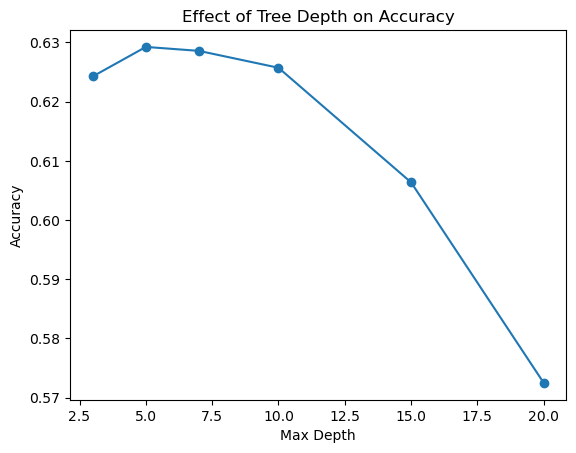

In [37]:
# Random Forest
rf_nc= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_nc.fit(X_train_nc, y_train)
rf_nc_pred = rf_nc.predict(X_test_nc)

print("=== Random Forest (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, rf_nc_pred))
print(classification_report(y_test, rf_nc_pred))
acc_list = []

depths = [3, 5, 7, 10, 15, 20]

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=d,
        random_state=42
    )
    
    rf.fit(X_train_nc, y_train)
    y_pred = rf.predict(X_test_nc)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Depth {d}: Accuracy = {acc:.4f}")

for d in depths:
    rf = RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42)
    rf.fit(X_train_nc, y_train)
    y_pred = rf.predict(X_test_nc)
    
    acc_list.append(accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt

plt.plot(depths, acc_list, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Accuracy")
plt.show()


In [38]:
# Feature importance
importance_nc = pd.DataFrame({
    "Feature": X_train_nc.columns,
    "Importance": rf_nc.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Non-Clinical):")
print(importance_nc)




Feature Importance (Non-Clinical):
     Feature  Importance
1  age_years    0.478990
0        bmi    0.468430
3     active    0.016729
5     gender    0.016685
4       alco    0.009608
2      smoke    0.009557


In [19]:
# -----------------------------
# 2. FULL MODEL
# -----------------------------
full_features = ["bmi", "age_years", "smoke", "active","bp_systolic","bp_diastolic", "cholesterol", "gluc", "gender", "alco"]
X_full = cardiodata[full_features]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.25, random_state=42, stratify=y
)

rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_full.fit(X_train_full, y_train)
rf_full_pred = rf_full.predict(X_test_full)

print("\n=== Random Forest (Full Features) ===")
print("Accuracy:", accuracy_score(y_test, rf_full_pred))
print(classification_report(y_test, rf_full_pred))

importance_full = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": rf_full.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Full Model):")
print(importance_full)




=== Random Forest (Full Features) ===
Accuracy: 0.7359154929577465
              precision    recall  f1-score   support

           0       0.71      0.81      0.76      8341
           1       0.77      0.66      0.71      8131

    accuracy                           0.74     16472
   macro avg       0.74      0.73      0.73     16472
weighted avg       0.74      0.74      0.73     16472


Feature Importance (Full Model):
        Feature  Importance
4   bp_systolic    0.486168
5  bp_diastolic    0.184700
1     age_years    0.125343
6   cholesterol    0.093836
0           bmi    0.072048
7          gluc    0.013356
3        active    0.009289
8        gender    0.006343
2         smoke    0.005070
9          alco    0.003847



=== Logistic Regression (Non-Clinical) ===
Accuracy: 0.6272462360369111
              precision    recall  f1-score   support

           0       0.63      0.64      0.64      8341
           1       0.63      0.61      0.62      8131

    accuracy                           0.63     16472
   macro avg       0.63      0.63      0.63     16472
weighted avg       0.63      0.63      0.63     16472



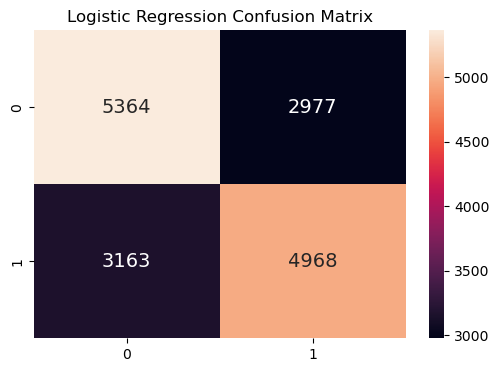

In [11]:
# -----------------------------
# 3. LOGISTIC REGRESSION-Non Clinical
# -----------------------------
scaler_lr = StandardScaler()
X_train_nc_scaled = scaler_lr.fit_transform(X_train_nc)
X_test_nc_scaled = scaler_lr.transform(X_test_nc)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_nc_scaled, y_train)
lr_pred = lr.predict(X_test_nc_scaled)

print("\n=== Logistic Regression (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()




=== Logistic Regression (Full) ===
Accuracy: 0.7285089849441476
              precision    recall  f1-score   support

           0       0.70      0.80      0.75      8341
           1       0.76      0.66      0.70      8131

    accuracy                           0.73     16472
   macro avg       0.73      0.73      0.73     16472
weighted avg       0.73      0.73      0.73     16472



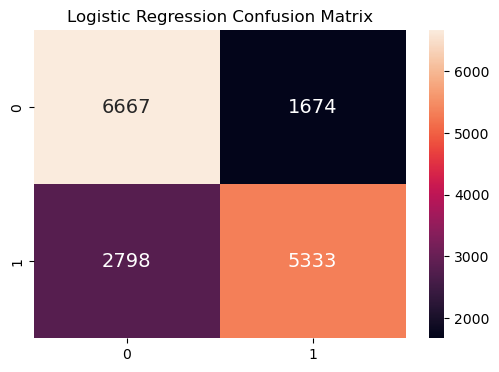

In [33]:
# -----------------------------
# 3. LOGISTIC REGRESSION-FULL
# -----------------------------
scaler_lr = StandardScaler()
X_train_full_scaled = scaler_lr.fit_transform(X_train_full)
X_test_full_scaled = scaler_lr.transform(X_test_full)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_full_scaled, y_train)
lr_pred = lr.predict(X_test_full_scaled)

print("\n=== Logistic Regression (Full) ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("Logistic Regression Confusion Matrix")
plt.show()




=== KNN (Non-Clinical) ===
Accuracy: 0.5740043710539097
              precision    recall  f1-score   support

           0       0.58      0.59      0.58      8341
           1       0.57      0.56      0.56      8131

    accuracy                           0.57     16472
   macro avg       0.57      0.57      0.57     16472
weighted avg       0.57      0.57      0.57     16472



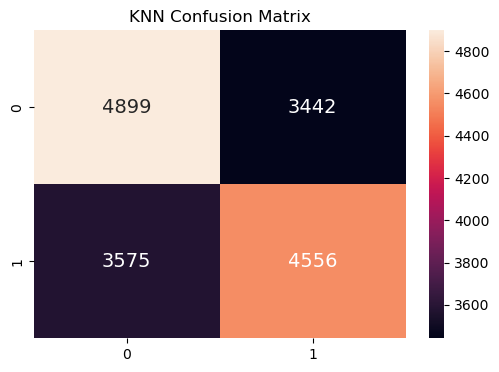


=== KNN (Full) ===
Accuracy: 0.6970009713453132
              precision    recall  f1-score   support

           0       0.69      0.72      0.71      8341
           1       0.70      0.67      0.69      8131

    accuracy                           0.70     16472
   macro avg       0.70      0.70      0.70     16472
weighted avg       0.70      0.70      0.70     16472



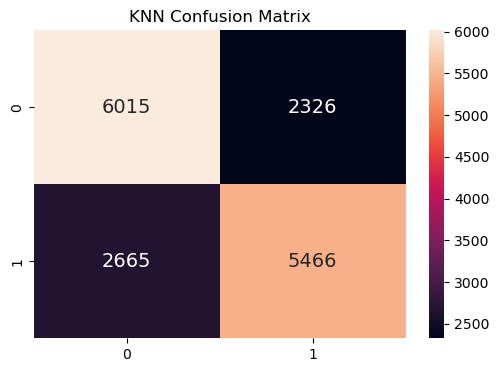

In [34]:
# -----------------------------
# 4. KNN-Non Clinical
# -----------------------------
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_nc)
X_test_knn = scaler_knn.transform(X_test_nc)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
knn_pred = knn.predict(X_test_knn)

print("\n=== KNN (Non-Clinical) ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

# -----------------------------
# 4. KNN-Full
# -----------------------------
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_full)
X_test_knn = scaler_knn.transform(X_test_full)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
knn_pred = knn.predict(X_test_knn)

print("\n=== KNN (Full) ===")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt=".0f", annot_kws={"size": 14})
plt.title("KNN Confusion Matrix")
plt.show()

       Predicted_Prob Risk_Level
53649        0.250000        Low
22735        0.028000        Low
5290         0.316667     Medium
43           0.240000        Low
35866        0.115000        Low

Risk distribution:
Low       5947
High      5662
Medium    4863
Name: Risk_Level, dtype: int64


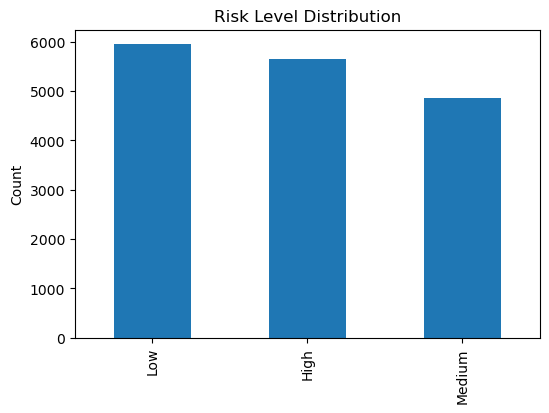

In [14]:
# Risk score using probabilities
rf_probs = rf_full.predict_proba(X_test_full)[:, 1]

def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

risk_labels = [risk_level(p) for p in rf_probs]

risk_df = X_test_full.copy()
risk_df["Actual"] = y_test.values
risk_df["Predicted_Prob"] = rf_probs
risk_df["Risk_Level"] = risk_labels

print(risk_df[["Predicted_Prob", "Risk_Level"]].head())

print("\nRisk distribution:")
print(risk_df["Risk_Level"].value_counts())

plt.figure(figsize=(6,4))
risk_df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.ylabel("Count")
plt.show()

       Predicted_Prob Risk_Level
53649        0.250000        Low
22735        0.028000        Low
5290         0.316667     Medium
43           0.240000        Low
35866        0.115000        Low

Risk distribution:
Low       5947
High      5662
Medium    4863
Name: Risk_Level, dtype: int64


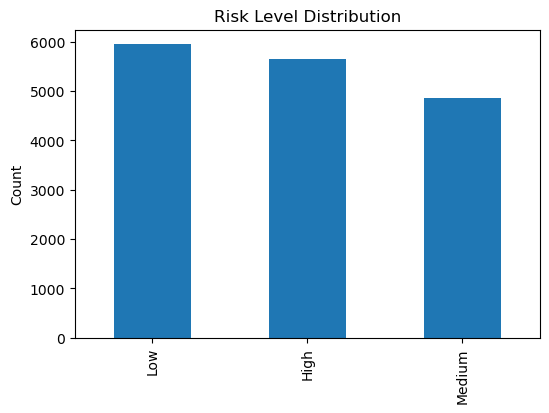

In [15]:
# Risk score using probabilities
rf_probs = rf_full.predict_proba(X_test_full)[:, 1]

def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

risk_labels = [risk_level(p) for p in rf_probs]

risk_df = X_test_full.copy()
risk_df["Actual"] = y_test.values
risk_df["Predicted_Prob"] = rf_probs
risk_df["Risk_Level"] = risk_labels

print(risk_df[["Predicted_Prob", "Risk_Level"]].head())

print("\nRisk distribution:")
print(risk_df["Risk_Level"].value_counts())

plt.figure(figsize=(6,4))
risk_df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.ylabel("Count")
plt.show()